# 1. Setup & Imports

In [1]:
import os
from pathlib import Path

os.environ["STATSBOMB_DATA"] = str(Path(".").resolve() / "data" / "statsbomb" / "data")

import statsbombpy.sb as sb
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from features import build_features, get_feature_columns

%matplotlib inline
sns.set_theme(style="whitegrid")
print("Setup complete.")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


# 2. Daten laden

Lade alle verfügbaren Competitions und deren Schüsse aus dem lokalen StatsBomb-Spiegel.

In [2]:
competitions = sb.competitions()
print(f"Verfügbare Competitions: {len(competitions)}")
display(competitions[["competition_name", "season_name", "competition_id", "season_id"]].drop_duplicates().head(20))

Verfügbare Competitions: 75


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,competition_name,season_name,competition_id,season_id
0,1. Bundesliga,2023/2024,9,281
1,1. Bundesliga,2015/2016,9,27
2,African Cup of Nations,2023,1267,107
3,Champions League,2018/2019,16,4
4,Champions League,2017/2018,16,1
5,Champions League,2016/2017,16,2
6,Champions League,2015/2016,16,27
7,Champions League,2014/2015,16,26
8,Champions League,2013/2014,16,25
9,Champions League,2012/2013,16,24


In [3]:
import json
import warnings
from tqdm.auto import tqdm

SHOTS_CACHE = Path("data") / "shots_raw.parquet"
STATSBOMB_ROOT = Path(os.environ["STATSBOMB_DATA"])


def _attach_key_pass_info(shots: pd.DataFrame, events: pd.DataFrame) -> pd.DataFrame:
    """Hängt Key-Pass-Eigenschaften (cross, cut_back, through_ball, high_pass)
    aus dem Pass-Event an jeden Schuss an."""
    passes = events[events["type"] == "Pass"].set_index("id")

    def _lookup(kp_id, col, default=False):
        if pd.isna(kp_id) or kp_id not in passes.index:
            return default
        val = passes.at[kp_id, col] if col in passes.columns else default
        return default if pd.isna(val) else val

    kp = shots["shot_key_pass_id"]
    shots["kp_cross"]        = kp.apply(lambda k: bool(_lookup(k, "pass_cross", False)))
    shots["kp_cut_back"]     = kp.apply(lambda k: bool(_lookup(k, "pass_cut_back", False)))
    shots["kp_through_ball"] = kp.apply(lambda k: bool(_lookup(k, "pass_through_ball", False)))
    shots["kp_high_pass"]    = kp.apply(lambda k: _lookup(k, "pass_height", "") == "High Pass")
    return shots


def _collect_local_match_ids() -> list[int]:
    """Liest alle match_ids direkt aus den lokalen StatsBomb-Match-JSON-Files."""
    ids: set[int] = set()
    for matches_file in (STATSBOMB_ROOT / "matches").glob("*/*.json"):
        try:
            with open(matches_file) as f:
                for m in json.load(f):
                    ids.add(m["match_id"])
        except (OSError, json.JSONDecodeError):
            continue
    return sorted(ids)


if SHOTS_CACHE.exists():
    shots_raw = pd.read_parquet(SHOTS_CACHE)
    print(f"Cache gefunden: {len(shots_raw)} Schüsse aus {SHOTS_CACHE} geladen.")
    if "kp_cross" not in shots_raw.columns:
        print("⚠️  Cache enthält keine kp_*-Spalten — lösche data/shots_raw.parquet "
              "und re-run, um Key-Pass-Features zu aktivieren.")
else:
    match_ids = _collect_local_match_ids()
    print(f"{len(match_ids)} Matches im lokalen StatsBomb-Mirror gefunden.")

    all_shots: list[pd.DataFrame] = []
    failed = 0

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for match_id in tqdm(match_ids, desc="Schüsse laden", unit="match"):
            try:
                events = sb.events(match_id=match_id)
                shots = events[events.type == "Shot"].copy()
                if not shots.empty:
                    shots = _attach_key_pass_info(shots, events)
                    all_shots.append(shots)
            except Exception:
                failed += 1
                continue

    shots_raw = pd.concat(all_shots, ignore_index=True)
    print(f"\nGeladen: {len(shots_raw)} Schüsse aus {len(match_ids) - failed} Matches "
          f"({failed} übersprungen).")

    SHOTS_CACHE.parent.mkdir(parents=True, exist_ok=True)
    shots_raw.to_parquet(SHOTS_CACHE, index=False)
    print(f"Cache geschrieben: {SHOTS_CACHE}")

print(f"\nSpalten: {list(shots_raw.columns)[:10]}...")
print(f"Shot types: {shots_raw['shot_type'].value_counts().to_dict()}")

Cache gefunden: 88023 Schüsse aus data/shots_raw.parquet geladen.

Spalten: ['bad_behaviour_card', 'ball_receipt_outcome', 'ball_recovery_offensive', 'ball_recovery_recovery_failure', 'block_deflection', 'carry_end_location', 'counterpress', 'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun']...
Shot types: {'Open Play': 82402, 'Free Kick': 4231, 'Penalty': 1361, 'Corner': 28, 'Kick Off': 1}


# 3. Schüsse filtern & bereinigen

- Penalties ausschließen (eigene xG ~0.76)
- Eigentore ausschließen
- Zielvariable `goal` erstellen
- Koordinaten extrahieren

In [4]:
# Penalties und Eigentore ausschließen
shots = shots_raw[shots_raw["shot_type"] != "Penalty"].copy()
shots = shots[shots["shot_outcome"] != "Own Goal"].copy()

# Zielvariable
shots["goal"] = (shots["shot_outcome"] == "Goal").astype(int)

# Koordinaten aus location extrahieren (Parquet liefert np.ndarray statt list)
def _coord(loc, i):
    if loc is None:
        return np.nan
    try:
        if len(loc) >= 2:
            return float(loc[i])
    except TypeError:
        return np.nan
    return np.nan

shots["x"] = shots["location"].apply(lambda loc: _coord(loc, 0))
shots["y"] = shots["location"].apply(lambda loc: _coord(loc, 1))

shots = shots.dropna(subset=["x", "y"])

print(f"Schüsse nach Bereinigung: {len(shots)}")
print(f"Torquote: {shots['goal'].mean():.1%}")
print(f"\nVerteilung shot_outcome:")
print(shots["shot_outcome"].value_counts())

Schüsse nach Bereinigung: 86662
Torquote: 10.1%

Verteilung shot_outcome:
shot_outcome
Off T               28411
Blocked             21677
Saved               20535
Goal                 8792
Wayward              4821
Post                 1798
Saved Off Target      349
Saved to Post         279
Name: count, dtype: int64


# 4. Feature Engineering

Alle Feature-Gruppen über `build_features()` aus `features.py` anwenden.

In [5]:
import importlib
import features
importlib.reload(features)
from features import build_features, get_feature_columns

shots = build_features(shots)
feature_cols = get_feature_columns()

print(f"Feature-Spalten ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  - {col}")

print(f"\nNaN-Anteil pro Feature:")
print(shots[feature_cols].isnull().mean().to_string())

# ---- Diagnose: was steckt tatsächlich in shot_freeze_frame? ----
print("\n--- freeze_frame-Diagnose ---")
sample = shots["shot_freeze_frame"].dropna().head(1)
if len(sample):
    ff = sample.iloc[0]
    print(f"Outer-Typ:   {type(ff).__name__}")
    if hasattr(ff, "__len__") and len(ff) > 0:
        p0 = ff[0]
        print(f"Inner-Typ:   {type(p0).__name__}")
        if hasattr(p0, "keys"):
            print(f"Inner-Keys:  {list(p0.keys())}")
        loc = p0.get("location") if hasattr(p0, "get") else None
        print(f"location:    {loc!r} ({type(loc).__name__})")
else:
    print("Keine non-null freeze_frames im DataFrame!")

Feature-Spalten (23):
  - distance_to_goal
  - angle_to_goal
  - angle_to_goal_rad
  - is_header
  - is_left_foot
  - situation_open_play
  - situation_free_kick
  - situation_corner
  - situation_other
  - preceding_cross
  - preceding_cutback
  - preceding_through_ball
  - preceding_high_pass
  - preceding_no_assist
  - goalkeeper_x
  - goalkeeper_y
  - goalkeeper_distance_to_goal_center
  - n_defenders_in_cone
  - min_defender_distance
  - pct_goal_blocked
  - pct_goal_free
  - gk_free_zone_coverage
  - net_open_goal_pct

NaN-Anteil pro Feature:
distance_to_goal                      0.0
angle_to_goal                         0.0
angle_to_goal_rad                     0.0
is_header                             0.0
is_left_foot                          0.0
situation_open_play                   0.0
situation_free_kick                   0.0
situation_corner                      0.0
situation_other                       0.0
preceding_cross                       0.0
preceding_cutback        

# 5. Train/Test-Split

Stratified Split nach Tor-Rate (80/20).

In [6]:
X = shots[feature_cols].copy()
y = shots["goal"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Trainingsset: {len(X_train)} Schüsse ({y_train.mean():.1%} Tore)")
print(f"Testset:      {len(X_test)} Schüsse ({y_test.mean():.1%} Tore)")

Trainingsset: 69329 Schüsse (10.1% Tore)
Testset:      17333 Schüsse (10.1% Tore)


# 6. Modell: Random Forest

In [7]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
print(f"Random Forest ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")
print(f"Random Forest Brier:   {brier_score_loss(y_test, rf_proba):.4f}")

Random Forest ROC-AUC: 0.8016
Random Forest Brier:   0.0765


# 7. Modell: XGBoost

In [8]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    device="cpu",
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
print(f"\nXGBoost ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")
print(f"XGBoost Brier:   {brier_score_loss(y_test, xgb_proba):.4f}")

[0]	validation_0-logloss:0.32184
[50]	validation_0-logloss:0.26570
[100]	validation_0-logloss:0.26292
[150]	validation_0-logloss:0.26245
[200]	validation_0-logloss:0.26220
[250]	validation_0-logloss:0.26217
[300]	validation_0-logloss:0.26207
[350]	validation_0-logloss:0.26207
[400]	validation_0-logloss:0.26216
[450]	validation_0-logloss:0.26223
[499]	validation_0-logloss:0.26242

XGBoost ROC-AUC: 0.8116
XGBoost Brier:   0.0755


# 8. Vergleich: professionelle xG-Modelle

Vergleich unserer Modelle mit dem StatsBomb xG, das direkt in den Schuss-Daten enthalten ist.

In [9]:
sb_xg = shots.loc[X_test.index, "shot_statsbomb_xg"]

def evaluate_model(name, y_true, y_pred_proba):
    return {
        "Model": name,
        "ROC-AUC": roc_auc_score(y_true, y_pred_proba),
        "Brier Score": brier_score_loss(y_true, y_pred_proba),
        "Log Loss": log_loss(y_true, y_pred_proba),
    }

results = pd.DataFrame([
    evaluate_model("Random Forest", y_test, rf_proba),
    evaluate_model("XGBoost", y_test, xgb_proba),
    evaluate_model("StatsBomb xG", y_test, sb_xg),
])

display(results.style.format({
    "ROC-AUC": "{:.4f}",
    "Brier Score": "{:.4f}",
    "Log Loss": "{:.4f}",
}).highlight_min(subset=["Brier Score", "Log Loss"], color="lightgreen")
 .highlight_max(subset=["ROC-AUC"], color="lightgreen"))

,Model,ROC-AUC,Brier Score,Log Loss
0,Random Forest,0.8016,0.0765,0.2679
1,XGBoost,0.8116,0.0755,0.2624
2,StatsBomb xG,0.8066,0.0754,0.2654


# 8b. Einzelschuss-Inspektion

Wähle einen zufälligen Schuss aus dem Testset und visualisiere ihn auf dem Spielfeld
inkl. Mit-/Gegenspieler-Positionen (freeze_frame). Darunter werden alle Feature-Werte
gezeigt sowie der xG-Wert der beiden eigenen Modelle und von StatsBomb.

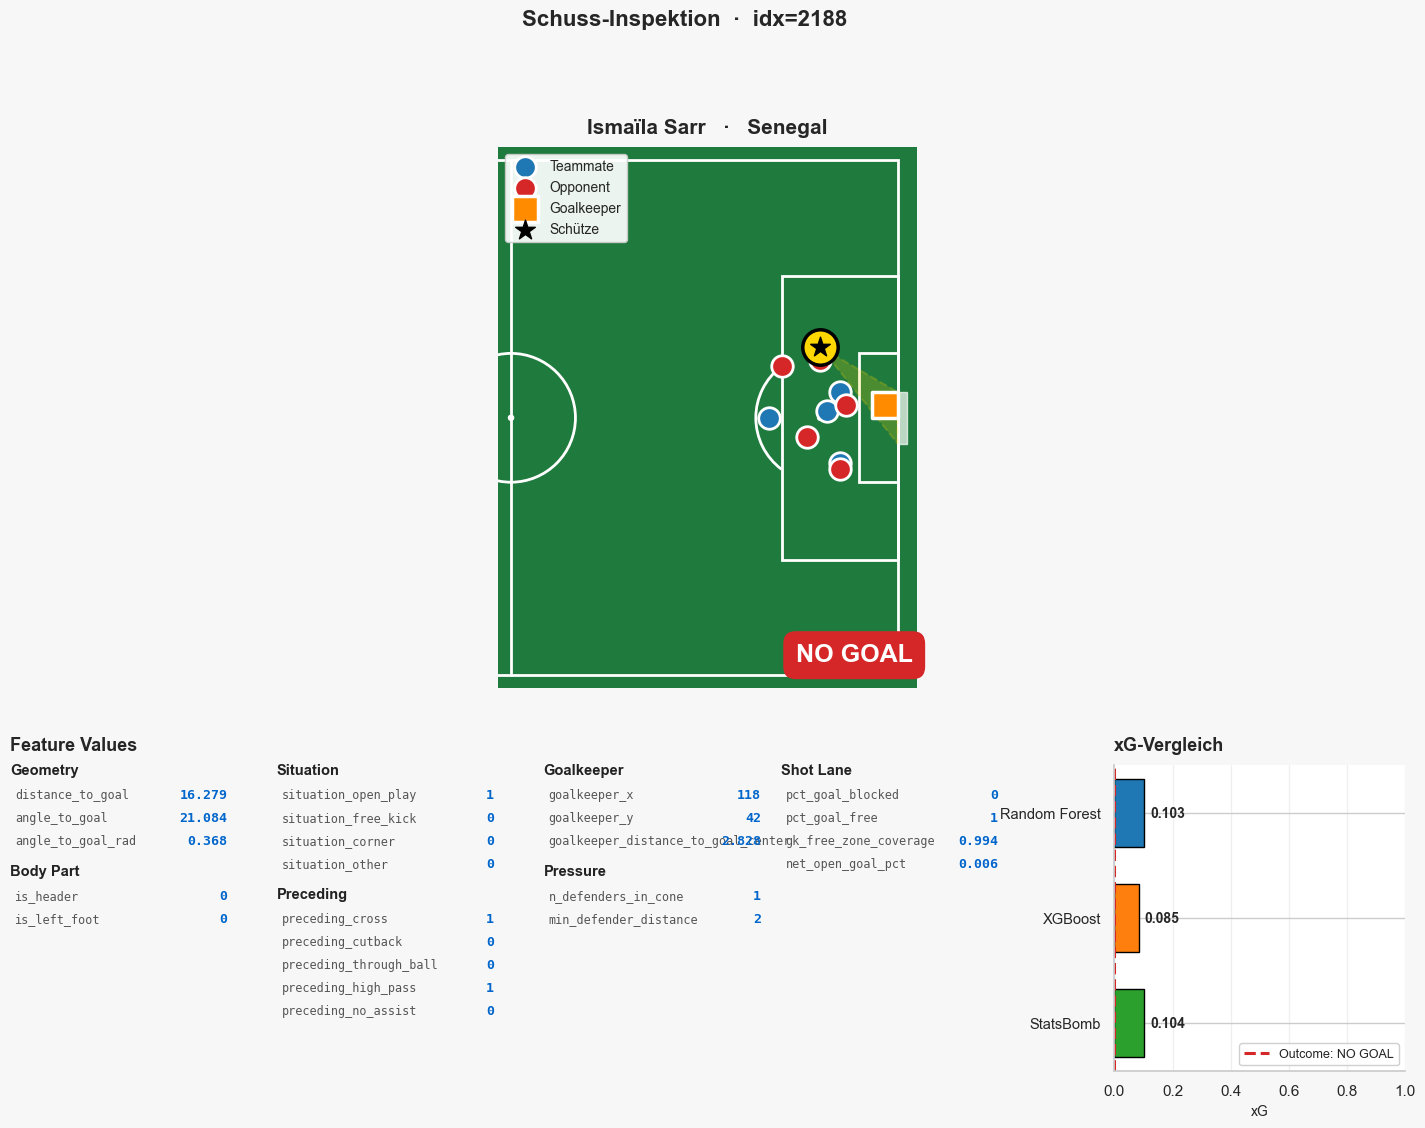

In [30]:
import random
from matplotlib.patches import Arc, Rectangle, Circle, Polygon


def draw_pitch(ax, facecolor="#1f7a3d", linecolor="white"):
    """StatsBomb-Pitch (120x80) zeichnen — Angriff nach rechts."""
    ax.set_facecolor(facecolor)
    ax.add_patch(Rectangle((0, 0), 120, 80, fill=False, edgecolor=linecolor, lw=2))
    ax.plot([60, 60], [0, 80], color=linecolor, lw=2)
    ax.add_patch(Circle((60, 40), 10, fill=False, edgecolor=linecolor, lw=2))
    ax.add_patch(Circle((60, 40), 0.4, color=linecolor))
    for x0 in [0, 102]:
        ax.add_patch(Rectangle((x0, 18), 18, 44, fill=False, edgecolor=linecolor, lw=2))
    for x0 in [0, 114]:
        ax.add_patch(Rectangle((x0, 30), 6, 20, fill=False, edgecolor=linecolor, lw=2))
    for x_goal, off in [(0, -1.5), (120, 0)]:
        ax.add_patch(Rectangle((x_goal + off, 36), 1.5, 8, color=linecolor, alpha=0.7))
    for xs in [12, 108]:
        ax.add_patch(Circle((xs, 40), 0.4, color=linecolor))
    ax.add_patch(Arc((12, 40), 20, 20, angle=0, theta1=-53, theta2=53, color=linecolor, lw=2))
    ax.add_patch(Arc((108, 40), 20, 20, angle=0, theta1=127, theta2=233, color=linecolor, lw=2))
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)


# --- zufälligen Schuss aus dem Testset ziehen ---
shot_idx = random.choice(X_test.index.tolist())
shot = shots.loc[shot_idx]
feat_vals = X_test.loc[shot_idx]

rf_pred  = float(rf.predict_proba(X_test.loc[[shot_idx]])[0, 1])
xgb_pred = float(xgb_model.predict_proba(X_test.loc[[shot_idx]])[0, 1])
sb_pred  = float(shots.loc[shot_idx, "shot_statsbomb_xg"])
actual   = int(shots.loc[shot_idx, "goal"])

# --- Figure-Layout: Pitch oben, darunter Features + xG-Bars ---
fig = plt.figure(figsize=(18, 12), facecolor="#f7f7f7")
gs = fig.add_gridspec(2, 3, height_ratios=[3, 1.7], width_ratios=[2, 1, 1],
                      hspace=0.18, wspace=0.30)
ax_pitch = fig.add_subplot(gs[0, :])
ax_feat  = fig.add_subplot(gs[1, :2])
ax_xg    = fig.add_subplot(gs[1, 2])

draw_pitch(ax_pitch)
sx, sy = float(shot["x"]), float(shot["y"])

# Sichtwinkel-Dreieck zwischen Schütze und Torpfosten
ax_pitch.add_patch(Polygon([(sx, sy), (120, 36), (120, 44)],
                           facecolor="#ffd700", alpha=0.20,
                           edgecolor="#ffd700", lw=1.5, linestyle="--", zorder=2))

# freeze_frame durchgehen
ff = shot.get("shot_freeze_frame")
gk_pos = None
tm_x, tm_y, op_x, op_y = [], [], [], []
if isinstance(ff, (list, np.ndarray)):
    for p in ff:
        if not isinstance(p, dict):
            continue
        loc = p.get("location")
        if not isinstance(loc, (list, np.ndarray)) or len(loc) != 2:
            continue
        px, py = float(loc[0]), float(loc[1])
        is_tm = bool(p.get("teammate", False))
        is_gk = (p.get("position") or {}).get("name") == "Goalkeeper"
        if is_gk and not is_tm:
            gk_pos = (px, py)
        elif is_tm:
            tm_x.append(px); tm_y.append(py)
        else:
            op_x.append(px); op_y.append(py)

if tm_x:
    ax_pitch.scatter(tm_x, tm_y, s=240, c="#1f77b4", edgecolors="white",
                     linewidths=2, zorder=5, label="Teammate")
if op_x:
    ax_pitch.scatter(op_x, op_y, s=240, c="#d62728", edgecolors="white",
                     linewidths=2, zorder=5, label="Opponent")
if gk_pos is not None:
    ax_pitch.scatter(*gk_pos, s=360, c="#ff8c00", marker="s", edgecolors="white",
                     linewidths=2.5, zorder=6, label="Goalkeeper")

# Schütze markant herausstellen
ax_pitch.scatter(sx, sy, s=650, c="#ffd700", edgecolors="black",
                 linewidths=2.5, zorder=10)
ax_pitch.scatter(sx, sy, s=220, c="black", marker="*", zorder=11, label="Schütze")

ax_pitch.set_xlim(58, 123)
ax_pitch.set_ylim(-2, 82)

player = shot.get("player", "?")
team   = shot.get("team", "?")
outcome = "GOAL ⚽" if actual == 1 else "NO GOAL"
oc_color = "#2ca02c" if actual == 1 else "#d62728"

ax_pitch.set_title(f"{player}   ·   {team}",
                   fontsize=15, fontweight="bold", pad=10)
ax_pitch.legend(loc="upper left", frameon=True, fontsize=10,
                facecolor="white", framealpha=0.92)
ax_pitch.text(0.99, 0.04, outcome, transform=ax_pitch.transAxes,
              fontsize=18, fontweight="bold", color="white",
              ha="right", va="bottom",
              bbox=dict(boxstyle="round,pad=0.5", facecolor=oc_color, edgecolor="none"))

# --- Feature panel ---
ax_feat.axis("off")
ax_feat.set_xlim(0, 1); ax_feat.set_ylim(0, 1)
ax_feat.set_title("Feature Values", fontsize=13, fontweight="bold", loc="left", pad=10)

groups = {
    "Geometry":   ["distance_to_goal", "angle_to_goal", "angle_to_goal_rad"],
    "Body Part":  ["is_header", "is_left_foot"],
    "Situation":  ["situation_open_play", "situation_free_kick", "situation_corner", "situation_other"],
    "Preceding":  ["preceding_cross", "preceding_cutback", "preceding_through_ball", "preceding_high_pass", "preceding_no_assist"],
    "Goalkeeper": ["goalkeeper_x", "goalkeeper_y", "goalkeeper_distance_to_goal_center"],
    "Pressure":   ["n_defenders_in_cone", "min_defender_distance"],
    "Shot Lane":  ["pct_goal_blocked", "pct_goal_free", "gk_free_zone_coverage", "net_open_goal_pct"],
}
col_layout = [
    ["Geometry", "Body Part"],
    ["Situation", "Preceding"],
    ["Goalkeeper", "Pressure"],
    ["Shot Lane"],
]
col_x_start = [0.00, 0.27, 0.54, 0.78]
col_w = 0.22

for col_i, group_names in enumerate(col_layout):
    y = 0.97
    for gname in group_names:
        ax_feat.text(col_x_start[col_i], y, gname,
                     fontsize=10.5, fontweight="bold", color="#222")
        y -= 0.08
        for f in groups[gname]:
            if f not in feat_vals.index:
                continue
            v = feat_vals[f]
            if isinstance(v, (float, np.floating)) and not float(v).is_integer():
                v_str = f"{v:.3f}"
            else:
                v_str = f"{int(v)}"
            ax_feat.text(col_x_start[col_i] + 0.005, y, f,
                         fontsize=8.5, family="monospace", color="#555")
            ax_feat.text(col_x_start[col_i] + col_w, y, v_str,
                         fontsize=9.5, family="monospace",
                         color="#0066cc", fontweight="bold", ha="right")
            y -= 0.075
        y -= 0.025

# --- xG bar chart ---
ax_xg.set_title("xG-Vergleich", fontsize=13, fontweight="bold", loc="left", pad=10)
names  = ["Random Forest", "XGBoost", "StatsBomb"]
vals   = [rf_pred, xgb_pred, sb_pred]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
y_pos  = np.arange(len(names))
bars = ax_xg.barh(y_pos, vals, color=colors, edgecolor="black", linewidth=1, height=0.65)
ax_xg.set_yticks(y_pos); ax_xg.set_yticklabels(names, fontsize=10.5)
ax_xg.invert_yaxis()
ax_xg.set_xlim(0, 1)
ax_xg.set_xlabel("xG", fontsize=10)
ax_xg.axvline(actual, color=oc_color, lw=2.2, ls="--", label=f"Outcome: {outcome}")
for bar, v in zip(bars, vals):
    if v < 0.82:
        ax_xg.text(v + 0.02, bar.get_y() + bar.get_height()/2, f"{v:.3f}",
                   va="center", ha="left", fontsize=10, fontweight="bold")
    else:
        ax_xg.text(v - 0.02, bar.get_y() + bar.get_height()/2, f"{v:.3f}",
                   va="center", ha="right", fontsize=10, fontweight="bold", color="white")
ax_xg.legend(loc="lower right", fontsize=9, framealpha=0.92)
ax_xg.grid(axis="x", alpha=0.3); ax_xg.set_axisbelow(True)
for s in ["top", "right"]:
    ax_xg.spines[s].set_visible(False)

plt.suptitle(f"Schuss-Inspektion  ·  idx={shot_idx}",
             fontsize=16, fontweight="bold", y=0.995)
plt.show()

# 9. Feature Importance (SHAP)

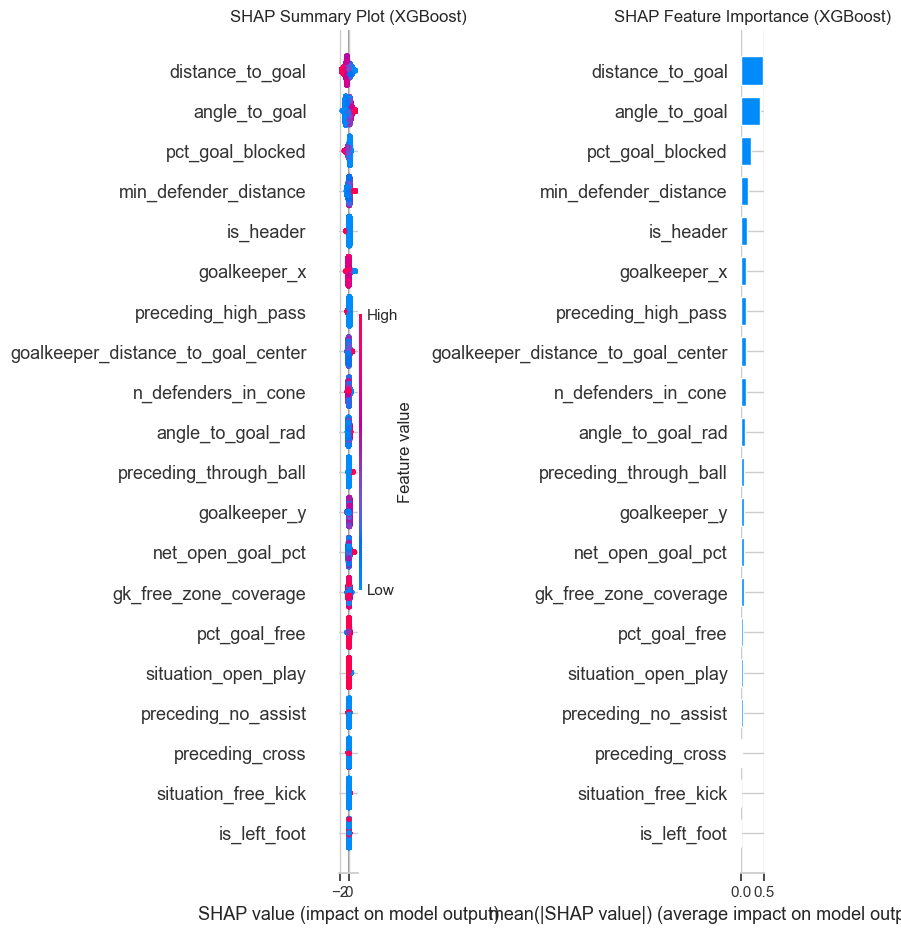

In [11]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_test, show=False)
axes[0].set_title("SHAP Summary Plot (XGBoost)")

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
axes[1].set_title("SHAP Feature Importance (XGBoost)")

plt.tight_layout()
plt.show()

## 9c. PCA — Feature-Redundanz prüfen

Standardisiert alle Features und führt eine PCA durch, um zu sehen,

- ob einige Features hochgradig linear voneinander abhängen (Korrelations-Heatmap),
- wie viele Hauptkomponenten man für 95 % bzw. 99 % der Gesamtvarianz braucht
  (effektive Dimensionalität),
- welche Features welche PCs dominieren (Loadings-Heatmap),
- ob es PCs mit ≈ 0 Varianz gibt — die wären ein Hinweis auf nahezu perfekte
  lineare Abhängigkeiten zwischen Features.

/var/folders/97/rtmptdls0c1528dcx38kr_vw0000gn/T/ipykernel_54629/657574302.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


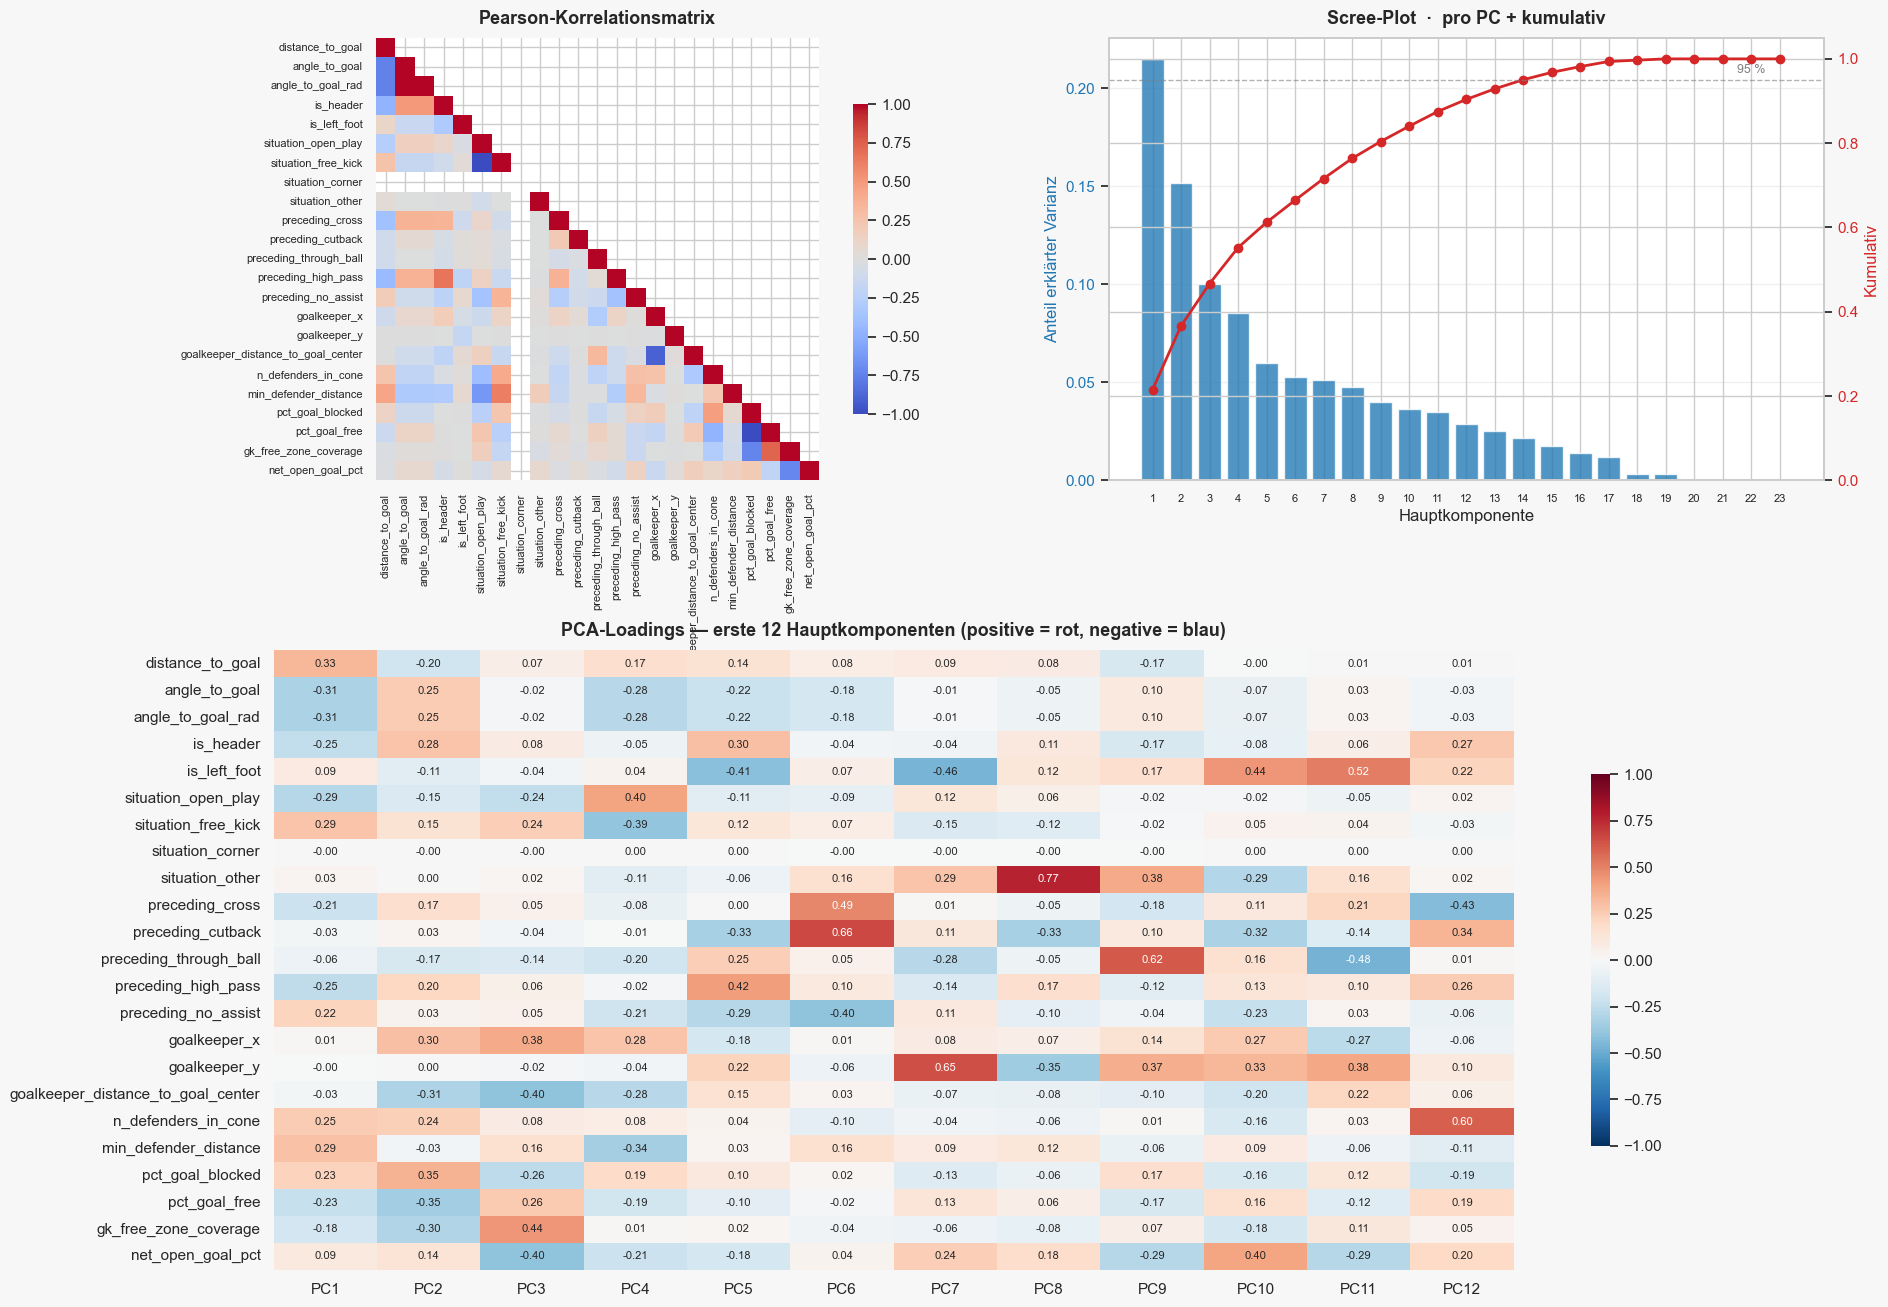

Effektive Dimensionalität (23 Features):
  95 % Varianz erreicht bei 14 Komponenten
  99 % Varianz erreicht bei 17 Komponenten

Stärkste paarweise lineare Abhängigkeiten (|r| > 0.7):
  pct_goal_blocked                     ↔ pct_goal_free                        r = -1.000
  angle_to_goal                        ↔ angle_to_goal_rad                    r = +1.000
  situation_open_play                  ↔ situation_free_kick                  r = -0.996
  goalkeeper_x                         ↔ goalkeeper_distance_to_goal_center   r = -0.905
  distance_to_goal                     ↔ angle_to_goal_rad                    r = -0.748
  distance_to_goal                     ↔ angle_to_goal                        r = -0.748
  pct_goal_free                        ↔ gk_free_zone_coverage                r = +0.730
  pct_goal_blocked                     ↔ gk_free_zone_coverage                r = -0.730
  gk_free_zone_coverage                ↔ net_open_goal_pct                    r = -0.726

Komponenten mit

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Standardisieren (Features haben sehr unterschiedliche Skalen) ---
X_all = shots[feature_cols].copy()
scaler = StandardScaler()
X_std = scaler.fit_transform(X_all)

# --- PCA mit allen Komponenten ---
pca = PCA(n_components=len(feature_cols))
pca.fit(X_std)
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

loadings = pd.DataFrame(
    pca.components_,
    columns=feature_cols,
    index=[f"PC{i+1}" for i in range(len(feature_cols))],
)

corr = X_all.corr()

# --- Plot ---
fig = plt.figure(figsize=(20, 16), facecolor="#f7f7f7")
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.4], width_ratios=[1, 1.05],
                      hspace=0.32, wspace=0.22)

# (1) Korrelations-Heatmap (unteres Dreieck)
ax1 = fig.add_subplot(gs[0, 0])
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            ax=ax1, cbar_kws={"shrink": 0.7}, square=True,
            xticklabels=True, yticklabels=True)
ax1.set_title("Pearson-Korrelationsmatrix", fontsize=13, fontweight="bold", pad=10)
ax1.tick_params(axis="x", rotation=90, labelsize=8)
ax1.tick_params(axis="y", labelsize=8)

# (2) Scree + kumulative Varianz
ax2 = fig.add_subplot(gs[0, 1])
x = np.arange(1, len(explained) + 1)
ax2.bar(x, explained, color="#1f77b4", alpha=0.78, label="pro PC")
ax2.set_xlabel("Hauptkomponente")
ax2.set_ylabel("Anteil erklärter Varianz", color="#1f77b4")
ax2.tick_params(axis="y", labelcolor="#1f77b4")
ax2.set_xticks(x)
ax2.tick_params(axis="x", labelsize=8)
ax2b = ax2.twinx()
ax2b.plot(x, cum_explained, color="#d62728", marker="o", lw=2, label="kumulativ")
ax2b.axhline(0.95, color="gray", ls="--", lw=1, alpha=0.6)
ax2b.text(len(explained) - 0.5, 0.96, "95 %", fontsize=9, color="gray", va="bottom", ha="right")
ax2b.set_ylabel("Kumulativ", color="#d62728")
ax2b.tick_params(axis="y", labelcolor="#d62728")
ax2b.set_ylim(0, 1.05)
ax2.set_title("Scree-Plot  ·  pro PC + kumulativ", fontsize=13, fontweight="bold", pad=10)
ax2.grid(axis="y", alpha=0.3)

# (3) Loadings-Heatmap (erste n PCs)
ax3 = fig.add_subplot(gs[1, :])
n_show = min(12, len(feature_cols))
sns.heatmap(loadings.iloc[:n_show].T, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            ax=ax3, annot=True, fmt=".2f",
            cbar_kws={"shrink": 0.6}, annot_kws={"size": 8})
ax3.set_title(f"PCA-Loadings — erste {n_show} Hauptkomponenten "
              "(positive = rot, negative = blau)",
              fontsize=13, fontweight="bold", pad=10)
ax3.set_xlabel(""); ax3.set_ylabel("")

plt.tight_layout()
plt.show()

# --- Numerische Diagnose ---
n_95 = int(np.argmax(cum_explained >= 0.95) + 1)
n_99 = int(np.argmax(cum_explained >= 0.99) + 1)
print(f"Effektive Dimensionalität ({len(feature_cols)} Features):")
print(f"  95 % Varianz erreicht bei {n_95} Komponenten")
print(f"  99 % Varianz erreicht bei {n_99} Komponenten")

# Stark korrelierte Paare
print("\nStärkste paarweise lineare Abhängigkeiten (|r| > 0.7):")
pairs = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            pairs.append((feature_cols[i], feature_cols[j], r))
pairs.sort(key=lambda t: -abs(t[2]))
if pairs:
    for f1, f2, r in pairs:
        print(f"  {f1:<36} ↔ {f2:<36} r = {r:+.3f}")
else:
    print("  (keine)")

# PCs mit sehr geringer Varianz = lineare Abhängigkeit zwischen Features
near_zero = [(i + 1, e) for i, e in enumerate(explained) if e < 0.005]
if near_zero:
    print(f"\nKomponenten mit <0.5 % Varianz "
          f"(Indikator für nahezu perfekte lineare Abhängigkeiten):")
    for pc_i, e in near_zero:
        top = loadings.iloc[pc_i - 1].abs().nlargest(3).index.tolist()
        print(f"  PC{pc_i}: {e * 100:.3f} %   dominante Features: {', '.join(top)}")
else:
    print("\nKeine PC mit <0.5 % Varianz — keine harten linearen Abhängigkeiten.")

# 10. Residualanalyse & Kalibrierung

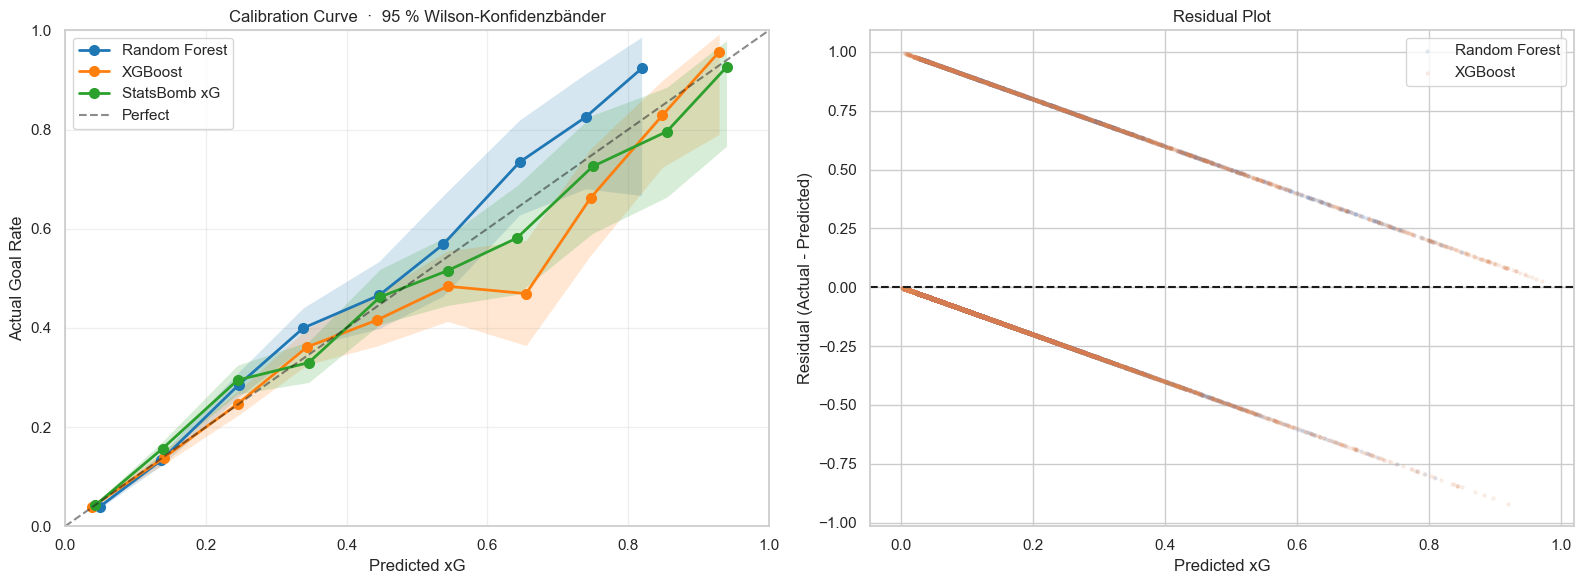

XGBoost  ·  Bin-Belegung (Equal-Width, 10 Bins):
 pred_mean     n  obs_rate    lo    hi
     0.039 12149     0.040 0.036 0.043
     0.141  2602     0.138 0.126 0.152
     0.245  1179     0.247 0.223 0.272
     0.344   650     0.362 0.326 0.399
     0.444   322     0.416 0.364 0.471
     0.543   186     0.484 0.413 0.555
     0.655    81     0.469 0.364 0.577
     0.747    71     0.662 0.546 0.761
     0.849    70     0.829 0.724 0.899
     0.929    23     0.957 0.790 0.992


In [14]:
def wilson_interval(k: int, n: int, z: float = 1.96) -> tuple[float, float]:
    """95%-Wilson-Score-Intervall für eine Binomial-Proportion."""
    if n == 0:
        return 0.0, 1.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return max(0.0, center - margin), min(1.0, center + margin)


def binned_calibration(y_true, y_pred, n_bins: int = 10) -> pd.DataFrame:
    """Gleichbreite Bins über [0,1]. Pro Bin: predicted_mean, observed_rate,
    Wilson-CI (lo, hi), Anzahl Shots."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(y_pred, edges) - 1, 0, n_bins - 1)
    rows = []
    for b in range(n_bins):
        mask = idx == b
        n = int(mask.sum())
        if n == 0:
            continue
        k = int(y_true[mask].sum())
        lo, hi = wilson_interval(k, n)
        rows.append((y_pred[mask].mean(), k / n, lo, hi, n))
    return pd.DataFrame(rows, columns=["pred_mean", "obs_rate", "lo", "hi", "n"])


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Kalibrierungsplot mit 95% Wilson-CI ---
ax = axes[0]
models = [
    ("Random Forest", rf_proba,     "#1f77b4"),
    ("XGBoost",       xgb_proba,    "#ff7f0e"),
    ("StatsBomb xG",  sb_xg.values, "#2ca02c"),
]
for name, proba, color in models:
    cal = binned_calibration(y_test.values, proba, n_bins=10)
    ax.fill_between(cal["pred_mean"], cal["lo"], cal["hi"],
                    color=color, alpha=0.18, linewidth=0)
    ax.plot(cal["pred_mean"], cal["obs_rate"],
            marker="o", color=color, label=name, lw=2, markersize=7)

ax.plot([0, 1], [0, 1], "k--", label="Perfect", alpha=0.5)
ax.set_xlabel("Predicted xG")
ax.set_ylabel("Actual Goal Rate")
ax.set_title("Calibration Curve  ·  95 % Wilson-Konfidenzbänder")
ax.legend(loc="upper left")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)

# --- Residualanalyse ---
ax2 = axes[1]
for name, proba in [("Random Forest", rf_proba), ("XGBoost", xgb_proba)]:
    residuals = y_test.values - proba
    ax2.scatter(proba, residuals, alpha=0.1, s=5, label=name)
ax2.axhline(y=0, color="k", linestyle="--")
ax2.set_xlabel("Predicted xG")
ax2.set_ylabel("Residual (Actual - Predicted)")
ax2.set_title("Residual Plot")
ax2.legend()

plt.tight_layout()
plt.show()

# Bin-Größen für die Mid-Range-Diagnose
print("XGBoost  ·  Bin-Belegung (Equal-Width, 10 Bins):")
print(binned_calibration(y_test.values, xgb_proba, n_bins=10)
      [["pred_mean", "n", "obs_rate", "lo", "hi"]]
      .round(3).to_string(index=False))

# Modelle speichern

In [15]:
import pickle

os.makedirs("models", exist_ok=True)

with open("models/random_forest.pkl", "wb") as f:
    pickle.dump(rf, f)

xgb_model.save_model("models/xgboost.json")

print("Modelle gespeichert:")
print("  - models/random_forest.pkl")
print("  - models/xgboost.json")

Modelle gespeichert:
  - models/random_forest.pkl
  - models/xgboost.json


# 11. PCA-XGBoost: 17 Komponenten

Pipeline `StandardScaler → PCA(17) → XGBoost`. Damit kein Data-Leakage entsteht,
wird die PCA **nur auf dem Trainingsset gefittet** und auf dem Testset nur
transformiert.

Vergleich gegen die drei Baselines: Random Forest, XGBoost (alle 23 Features),
StatsBomb xG.

In [16]:
from sklearn.pipeline import Pipeline

N_COMPONENTS = 17

# Pipeline: Standardize → PCA → XGBoost-Input
pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=N_COMPONENTS, random_state=42)),
])

X_train_pca = pca_pipeline.fit_transform(X_train)
X_test_pca  = pca_pipeline.transform(X_test)

var_kept = pca_pipeline.named_steps["pca"].explained_variance_ratio_.sum()
print(f"PCA mit {N_COMPONENTS} Komponenten erklärt {var_kept:.1%} der Gesamtvarianz "
      f"(aus {X_train.shape[1]} Original-Features).")

# XGBoost mit identischen Hyperparametern wie Section 7
xgb_pca = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    device="cpu",
)
xgb_pca.fit(
    X_train_pca, y_train,
    eval_set=[(X_test_pca, y_test)],
    verbose=100,
)

xgb_pca_proba = xgb_pca.predict_proba(X_test_pca)[:, 1]
print(f"\nXGBoost (PCA-{N_COMPONENTS}) ROC-AUC: {roc_auc_score(y_test, xgb_pca_proba):.4f}")
print(f"XGBoost (PCA-{N_COMPONENTS}) Brier:   {brier_score_loss(y_test, xgb_pca_proba):.4f}")
print(f"XGBoost (PCA-{N_COMPONENTS}) LogLoss: {log_loss(y_test, xgb_pca_proba):.4f}")

PCA mit 17 Komponenten erklärt 99.4% der Gesamtvarianz (aus 23 Original-Features).
[0]	validation_0-logloss:0.32250
[100]	validation_0-logloss:0.26390
[200]	validation_0-logloss:0.26302
[300]	validation_0-logloss:0.26289
[400]	validation_0-logloss:0.26315
[499]	validation_0-logloss:0.26346

XGBoost (PCA-17) ROC-AUC: 0.8105
XGBoost (PCA-17) Brier:   0.0759
XGBoost (PCA-17) LogLoss: 0.2635


,Model,ROC-AUC,Brier Score,Log Loss
0,Random Forest,0.8016,0.0765,0.2679
1,XGBoost (23 features),0.8116,0.0755,0.2624
2,XGBoost (PCA-17),0.8105,0.0759,0.2635
3,StatsBomb xG,0.8066,0.0754,0.2654


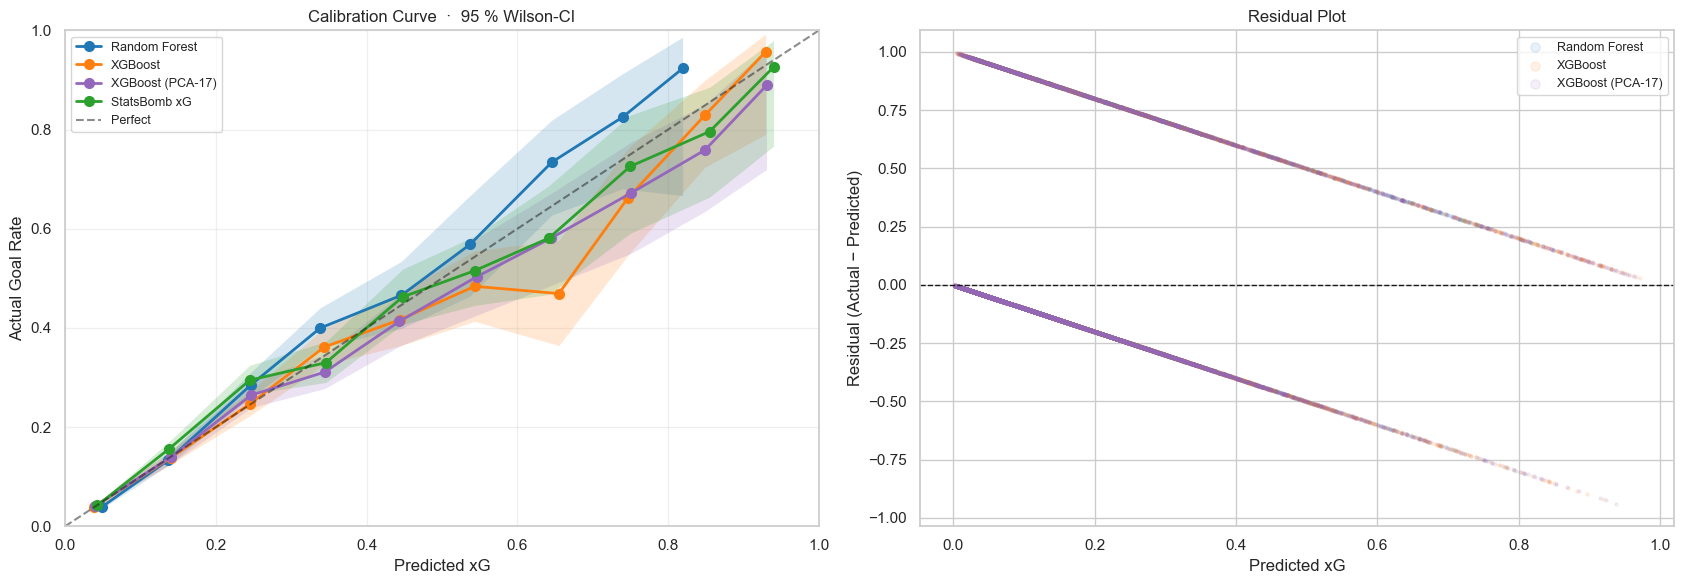

In [17]:
# --- Metrik-Vergleich aller vier Modelle ---
results_pca = pd.DataFrame([
    evaluate_model("Random Forest",                  y_test, rf_proba),
    evaluate_model("XGBoost (23 features)",          y_test, xgb_proba),
    evaluate_model(f"XGBoost (PCA-{N_COMPONENTS})",  y_test, xgb_pca_proba),
    evaluate_model("StatsBomb xG",                   y_test, sb_xg),
])

display(results_pca.style.format({
    "ROC-AUC": "{:.4f}",
    "Brier Score": "{:.4f}",
    "Log Loss": "{:.4f}",
}).highlight_min(subset=["Brier Score", "Log Loss"], color="lightgreen")
 .highlight_max(subset=["ROC-AUC"], color="lightgreen"))

# --- Visueller Vergleich: Kalibrierung + Residuen ---
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Kalibrierung mit 95% Wilson-CI für alle 4 Modelle
ax = axes[0]
model_specs = [
    ("Random Forest",                  rf_proba,       "#1f77b4"),
    ("XGBoost",                        xgb_proba,      "#ff7f0e"),
    (f"XGBoost (PCA-{N_COMPONENTS})",  xgb_pca_proba,  "#9467bd"),
    ("StatsBomb xG",                   sb_xg.values,   "#2ca02c"),
]
for name, proba, color in model_specs:
    cal = binned_calibration(y_test.values, proba, n_bins=10)
    ax.fill_between(cal["pred_mean"], cal["lo"], cal["hi"],
                    color=color, alpha=0.18, linewidth=0)
    ax.plot(cal["pred_mean"], cal["obs_rate"],
            marker="o", color=color, label=name, lw=2, markersize=7)

ax.plot([0, 1], [0, 1], "k--", label="Perfect", alpha=0.5)
ax.set_xlabel("Predicted xG")
ax.set_ylabel("Actual Goal Rate")
ax.set_title("Calibration Curve  ·  95 % Wilson-CI")
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(alpha=0.3)

# Residual-Plot
ax2 = axes[1]
residual_specs = [
    ("Random Forest",                  rf_proba,       "#1f77b4"),
    ("XGBoost",                        xgb_proba,      "#ff7f0e"),
    (f"XGBoost (PCA-{N_COMPONENTS})",  xgb_pca_proba,  "#9467bd"),
]
for name, proba, color in residual_specs:
    residuals = y_test.values - proba
    ax2.scatter(proba, residuals, alpha=0.10, s=5, c=color, label=name)
ax2.axhline(y=0, color="k", linestyle="--", lw=1)
ax2.set_xlabel("Predicted xG")
ax2.set_ylabel("Residual (Actual − Predicted)")
ax2.set_title("Residual Plot")
ax2.legend(loc="upper right", fontsize=9, markerscale=3)

plt.tight_layout()
plt.show()

# 12. Ablation: Impact der Coverage-Features

Wir trainieren ein zusätzliches XGBoost-Modell, das die vier Coverage-Features
komplett ignoriert (`pct_goal_blocked`, `pct_goal_free`, `gk_free_zone_coverage`,
`net_open_goal_pct`) — also alle Features, die beschreiben, **wie viel vom Tor
für den Angreifer tatsächlich offen ist**.

Dann vergleichen wir per **5 Seeds × 10-fold Stratified Cross-Validation =
50 Evaluationen** pro Modelltyp:

- **XGBoost (PCA-17, alle Features)** — unser bestes Modell aus Section 11
- **XGBoost (ohne Coverage-Features)** — der neue, einfachere Vergleichskandidat
- **StatsBomb xG** — die Referenz

Differenz `PCA-17 minus No-Coverage` zeigt direkt, wie viel die vier
Coverage-Features beitragen. Mehrere Seeds geben uns Konfidenz, dass der
Effekt nicht von der zufälligen Fold-Aufteilung abhängt.


In [ ]:
from sklearn.model_selection import StratifiedKFold
from tqdm.auto import tqdm

# --- Coverage-Features definieren ---
COVERAGE_FEATURES = ["pct_goal_blocked", "pct_goal_free",
                     "gk_free_zone_coverage", "net_open_goal_pct"]
NO_COVERAGE_FEATURES = [f for f in feature_cols if f not in COVERAGE_FEATURES]
print(f"Coverage-Features ausgeschlossen: {COVERAGE_FEATURES}")
print(f"Verbleibende Features im No-Coverage-Modell: "
      f"{len(NO_COVERAGE_FEATURES)} von {len(feature_cols)}")

# --- CV-Setup: 5 Seeds × 10 Folds = 50 Evaluationen pro Modelltyp ---
N_SPLITS = 10
SEEDS = [42, 7, 1234, 2024, 99]
TOTAL = len(SEEDS) * N_SPLITS
print(f"\n{len(SEEDS)} Seeds × {N_SPLITS} Folds = {TOTAL} Evaluationen pro Modelltyp")
print("Erwartete Laufzeit: ca. 30–60 Minuten (100 XGBoost-Fits)")

X_full     = shots[feature_cols].reset_index(drop=True)
X_full_nc  = shots[NO_COVERAGE_FEATURES].reset_index(drop=True)
y_full     = shots["goal"].reset_index(drop=True)
sb_full    = shots["shot_statsbomb_xg"].reset_index(drop=True)

results = {
    "XGBoost (PCA-17, alle Features)":  {"auc": [], "brier": [], "logloss": [], "seed": [], "fold": []},
    "XGBoost (ohne Coverage-Features)": {"auc": [], "brier": [], "logloss": [], "seed": [], "fold": []},
    "StatsBomb xG":                     {"auc": [], "brier": [], "logloss": [], "seed": [], "fold": []},
}

# random_state wird PRO Seed gesetzt; nicht in den festen Params
xgb_params = dict(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", device="cpu",
)

pbar = tqdm(total=TOTAL, desc="Seed × Fold", unit="run")
for seed in SEEDS:
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X_full, y_full)):
        X_tr,    X_te    = X_full.iloc[tr_idx],    X_full.iloc[te_idx]
        X_tr_nc, X_te_nc = X_full_nc.iloc[tr_idx], X_full_nc.iloc[te_idx]
        y_tr,    y_te    = y_full.iloc[tr_idx],    y_full.iloc[te_idx]
        sb_te            = sb_full.iloc[te_idx].values

        # PCA-17 Pipeline
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("pca",    PCA(n_components=17, random_state=seed)),
        ])
        X_tr_pca = pipe.fit_transform(X_tr)
        X_te_pca = pipe.transform(X_te)
        m_pca = xgb.XGBClassifier(random_state=seed, **xgb_params).fit(
            X_tr_pca, y_tr, verbose=False)
        pred_pca = m_pca.predict_proba(X_te_pca)[:, 1]

        # No-Coverage Modell
        m_nc = xgb.XGBClassifier(random_state=seed, **xgb_params).fit(
            X_tr_nc, y_tr, verbose=False)
        pred_nc = m_nc.predict_proba(X_te_nc)[:, 1]

        valid_sb = ~pd.isna(sb_te)

        for key, pred in [
            ("XGBoost (PCA-17, alle Features)",  pred_pca),
            ("XGBoost (ohne Coverage-Features)", pred_nc),
        ]:
            results[key]["auc"].append(roc_auc_score(y_te, pred))
            results[key]["brier"].append(brier_score_loss(y_te, pred))
            results[key]["logloss"].append(log_loss(y_te, pred))
            results[key]["seed"].append(seed)
            results[key]["fold"].append(fold_idx)

        results["StatsBomb xG"]["auc"].append(roc_auc_score(y_te[valid_sb], sb_te[valid_sb]))
        results["StatsBomb xG"]["brier"].append(brier_score_loss(y_te[valid_sb], sb_te[valid_sb]))
        results["StatsBomb xG"]["logloss"].append(log_loss(y_te[valid_sb], sb_te[valid_sb]))
        results["StatsBomb xG"]["seed"].append(seed)
        results["StatsBomb xG"]["fold"].append(fold_idx)

        pbar.update(1)
pbar.close()

print(f"\nFertig: {len(results['XGBoost (PCA-17, alle Features)']['auc'])} "
      f"Evaluationen pro Modelltyp.")


In [ ]:
from scipy.stats import wilcoxon

# --- Summary-Tabelle ---
summary_rows = []
for model_name, scores in results.items():
    row = {"Modell": model_name, "N": len(scores["auc"])}
    for metric in ["auc", "brier", "logloss"]:
        m, s = np.mean(scores[metric]), np.std(scores[metric])
        row[metric.upper()] = f"{m:.4f} ± {s:.4f}"
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)
print(f"Mittelwerte ± Standardabweichung über {len(SEEDS)} Seeds × {N_SPLITS} Folds "
      f"= {len(SEEDS)*N_SPLITS} Evaluationen:")
display(summary_df)

# --- Box-Plots pro Metrik (mit allen 50 Punkten) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5), facecolor="#f7f7f7")
metrics_info = [
    ("auc",     "ROC-AUC",     "höher = besser"),
    ("brier",   "Brier Score", "niedriger = besser"),
    ("logloss", "Log Loss",    "niedriger = besser"),
]
model_names = list(results.keys())
colors = ["#9467bd", "#d62728", "#2ca02c"]
rng = np.random.default_rng(42)

for ax, (metric, title, hint) in zip(axes, metrics_info):
    data = [results[m][metric] for m in model_names]
    bp = ax.boxplot(
        data,
        labels=[m.replace(" (", "\n(") for m in model_names],
        patch_artist=True, widths=0.55, showmeans=True,
        meanprops={"marker": "D", "markerfacecolor": "yellow",
                   "markersize": 9, "markeredgecolor": "black"},
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color); patch.set_alpha(0.72)
    for median in bp["medians"]:
        median.set_color("black"); median.set_linewidth(2)

    for i, d in enumerate(data):
        jitter = rng.uniform(-0.10, 0.10, size=len(d))
        ax.scatter(i + 1 + jitter, d, color="black", s=14, alpha=0.45, zorder=10)

    ax.set_title(f"{title}\n({hint})", fontsize=13, fontweight="bold", pad=10)
    ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
    ax.tick_params(axis="x", labelsize=9)

plt.suptitle(f"Cross-Validation  ·  {len(SEEDS)} Seeds × {N_SPLITS} Folds "
             f"= {len(SEEDS)*N_SPLITS} Evaluationen pro Modell",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --- Gepaarte Differenz: PCA-17 minus No-Coverage ---
diff_auc     = (np.array(results["XGBoost (PCA-17, alle Features)"]["auc"])
              - np.array(results["XGBoost (ohne Coverage-Features)"]["auc"]))
diff_brier   = (np.array(results["XGBoost (PCA-17, alle Features)"]["brier"])
              - np.array(results["XGBoost (ohne Coverage-Features)"]["brier"]))
diff_logloss = (np.array(results["XGBoost (PCA-17, alle Features)"]["logloss"])
              - np.array(results["XGBoost (ohne Coverage-Features)"]["logloss"]))

# Per-Seed-Aggregation
seeds_arr = np.array(results["XGBoost (PCA-17, alle Features)"]["seed"])
per_seed = pd.DataFrame(index=["ΔAUC", "ΔBrier", "ΔLogLoss"])
for seed in SEEDS:
    mask = seeds_arr == seed
    per_seed[f"Seed {seed}"] = [diff_auc[mask].mean(),
                                diff_brier[mask].mean(),
                                diff_logloss[mask].mean()]
per_seed["Overall Mean"] = [diff_auc.mean(), diff_brier.mean(), diff_logloss.mean()]
per_seed["Overall Std"]  = [diff_auc.std(),  diff_brier.std(),  diff_logloss.std()]
print("\nGepaarte Differenz (PCA-17 minus No-Coverage), aggregiert pro Seed:")
print("(positives ΔAUC ⇒ PCA-17 besser; negatives ΔBrier/ΔLogLoss ⇒ PCA-17 besser)")
display(per_seed.round(5))

# === Wilcoxon Signed-Rank Test ============================================
# Non-parametrischer Test: ist der Median der gepaarten Differenzen ≠ 0?
# H0: Median(ΔMetrik) = 0 (kein Unterschied zwischen den Modellen)
# H1 (one-sided): das jeweilige Modell ist tatsächlich besser
wilcoxon_tests = [
    ("ΔAUC",     diff_auc,     "greater", "PCA-17 hat höhere AUC"),
    ("ΔBrier",   diff_brier,   "less",    "PCA-17 hat niedrigeren Brier (besser)"),
    ("ΔLogLoss", diff_logloss, "less",    "PCA-17 hat niedrigeren LogLoss (besser)"),
]
wilcoxon_rows = []
test_results = {}
for name, vals, alt, h1_text in wilcoxon_tests:
    stat_2s, p_2s = wilcoxon(vals, alternative="two-sided", zero_method="wilcox")
    _,       p_1s = wilcoxon(vals, alternative=alt,         zero_method="wilcox")
    median = float(np.median(vals))
    test_results[name] = {"W": stat_2s, "p_two": p_2s, "p_one": p_1s,
                          "median": median, "alt": alt}
    wilcoxon_rows.append({
        "Metrik":         name,
        "Median Diff":    f"{median:+.5f}",
        "W-Statistik":    f"{stat_2s:.1f}",
        "p (two-sided)":  f"{p_2s:.3g}",
        "p (one-sided)":  f"{p_1s:.3g}",
        "H1":             h1_text,
        "Signifikant α=0.05": "✓ ja" if p_2s < 0.05 else "✗ nein",
        "Signifikant α=0.01": "✓ ja" if p_2s < 0.01 else "✗ nein",
    })
wilcoxon_df = pd.DataFrame(wilcoxon_rows)
print("\n" + "=" * 75)
print("Wilcoxon Signed-Rank Test — PCA-17 vs No-Coverage")
print("=" * 75)
print(f"Stichprobengröße: {len(diff_auc)} gepaarte Folds")
print("H0: Median der gepaarten Differenz = 0   (kein Unterschied)")
print("H1: einseitig in Richtung 'PCA-17 besser'")
display(wilcoxon_df)

# === Histogramme mit Wilcoxon-p-Wert pro Plot =============================
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), facecolor="#f7f7f7")
hist_info = [
    ("ΔAUC",     diff_auc,     "positiv ⇒ PCA-17 besser"),
    ("ΔBrier",   diff_brier,   "negativ ⇒ PCA-17 besser"),
    ("ΔLogLoss", diff_logloss, "negativ ⇒ PCA-17 besser"),
]
for ax, (name, vals, hint) in zip(axes, hist_info):
    ax.hist(vals, bins=20, color="#9467bd", alpha=0.75, edgecolor="black")
    ax.axvline(0,           color="black",   lw=2,   ls="--", label="Gleichstand (H0)")
    ax.axvline(vals.mean(), color="#d62728", lw=2.5, label=f"Mean = {vals.mean():+.4f}")
    ax.axvline(np.median(vals), color="#ff7f0e", lw=2.5,
               label=f"Median = {np.median(vals):+.4f}")

    tr = test_results[name]
    sig_color = "#2ca02c" if tr["p_two"] < 0.05 else "#888888"
    sig_text = "signifikant" if tr["p_two"] < 0.05 else "n.s."
    ax.text(0.03, 0.97,
            f"Wilcoxon Signed-Rank\n"
            f"W = {tr['W']:.0f}\n"
            f"p (two-sided) = {tr['p_two']:.3g}\n"
            f"p (one-sided) = {tr['p_one']:.3g}\n"
            f"→ {sig_text} (α=0.05)",
            transform=ax.transAxes, fontsize=9, va="top", ha="left",
            family="monospace",
            bbox=dict(boxstyle="round,pad=0.45", facecolor="white",
                      edgecolor=sig_color, linewidth=1.6))

    ax.set_title(f"{name}\n({hint})", fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel(name)
    ax.set_ylabel(f"Anzahl Folds (von {len(vals)})")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.3); ax.set_axisbelow(True)

plt.suptitle(f"Gepaarte Differenz + Wilcoxon-Test  ·  "
             f"{len(diff_auc)} Folds (PCA-17 minus No-Coverage)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --- Win-Rate ---
wins_auc   = int((diff_auc   > 0).sum())
wins_brier = int((diff_brier < 0).sum())
wins_ll    = int((diff_logloss < 0).sum())
print(f"\nIn wievielen der {len(diff_auc)} Folds gewinnt PCA-17 absolut?")
print(f"  AUC:     {wins_auc}/{len(diff_auc)}  ({wins_auc/len(diff_auc):.1%})")
print(f"  Brier:   {wins_brier}/{len(diff_brier)}  ({wins_brier/len(diff_brier):.1%})")
print(f"  LogLoss: {wins_ll}/{len(diff_logloss)}  ({wins_ll/len(diff_logloss):.1%})")

print("\nWilcoxon-Fazit:")
for name in ["ΔAUC", "ΔBrier", "ΔLogLoss"]:
    tr = test_results[name]
    verdict = "PCA-17 ist signifikant besser" if tr["p_one"] < 0.05 else "kein signifikanter Unterschied"
    print(f"  {name}: einseitiges p = {tr['p_one']:.3g}  →  {verdict}")


# 12b. Deep-Dive: Wie wirkt das Feature `net_open_goal_pct`?

Das vorige Ablations-Experiment zeigt die **globale** Auswirkung der vier
Coverage-Features. Jetzt schauen wir uns das wichtigste davon — `net_open_goal_pct`
(geschätzter Anteil der Torfläche, der weder durch Feldspieler noch durch den
Torwart abgedeckt ist) — auf der Ebene einzelner Schüsse an:

- **Wie wichtig** ist das Feature im Vergleich zu den klassischen Größen Distanz und Winkel?
- **Liefern die Features ähnliche Information** (sind sie redundant), oder unabhängig?
- **Wann** treibt das Feature die xG-Vorhersage nach oben, wann nach unten?

Alle Plots basieren auf den SHAP-Werten aus Section 9.


In [ ]:
focus_features = ["net_open_goal_pct", "distance_to_goal", "angle_to_goal"]
missing = [f for f in focus_features if f not in X_test.columns]
if missing:
    raise ValueError(f"Fehlende Feature-Spalten: {missing} — shot_lane aktiviert?")

mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns,
    name="mean_|SHAP|",
).sort_values(ascending=False)

print("Mittlere Wichtigkeit (mean |SHAP|) der Fokus-Features:")
print(mean_abs_shap.loc[focus_features].to_string())
print(f"\nRang im Gesamt-Feature-Set:")
for f in focus_features:
    print(f"  {f}: Rang {list(mean_abs_shap.index).index(f) + 1} "
          f"von {len(mean_abs_shap)} Features")

# SHAP-Werte fokussieren
focus_idx = [X_test.columns.get_loc(f) for f in focus_features]
shap_focus = pd.DataFrame(shap_values[:, focus_idx], columns=focus_features)
shap_corr = shap_focus.corr()

fig, axes = plt.subplots(1, 3, figsize=(22, 6.5), facecolor="#f7f7f7")

# (1) Wichtigkeit
ax = axes[0]
mean_abs_shap.loc[focus_features].plot.barh(
    ax=ax, color=["#d62728", "#1f77b4", "#2ca02c"], edgecolor="black")
ax.set_xlabel("Mittlerer absoluter SHAP-Wert\n(je größer, desto stärker beeinflusst "
              "das Feature die Vorhersage)", fontsize=10)
ax.set_title("Wie wichtig ist jedes Feature?\n"
             "(Vergleich: neues Feature vs. klassische Geometrie)",
             fontsize=12, fontweight="bold", pad=10)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

# (2) Redundanz
ax = axes[1]
sns.heatmap(shap_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 13, "weight": "bold"})
ax.set_title("Liefern die Features ähnliche Information?\n"
             "(±1 = Features sagen praktisch dasselbe; 0 = unabhängig)",
             fontsize=12, fontweight="bold", pad=10)

# (3) Wirkung in Abhängigkeit von der Distanz
ax = axes[2]
sc = ax.scatter(
    X_test["distance_to_goal"],
    shap_focus["net_open_goal_pct"],
    c=X_test["net_open_goal_pct"],
    cmap="viridis", s=8, alpha=0.5,
)
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("Distanz zum Tor (Yards)", fontsize=10)
ax.set_ylabel("Einfluss von 'net_open_goal_pct' auf die xG-Vorhersage\n"
              "(SHAP-Wert: + erhöht xG, − senkt xG)", fontsize=10)
ax.set_title("Wann hebt das Feature die Vorhersage —\nund wann drückt es sie?",
             fontsize=12, fontweight="bold", pad=10)
plt.colorbar(sc, ax=ax, label="net_open_goal_pct (Anteil freier Torfläche)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Detail: Dependence-Plot mit Interaktion ---
fig, ax = plt.subplots(figsize=(11, 6.5), facecolor="#f7f7f7")
shap.dependence_plot(
    "net_open_goal_pct", shap_values, X_test,
    interaction_index="distance_to_goal", ax=ax, show=False,
)
ax.set_xlabel("net_open_goal_pct  ·  Anteil der Torfläche, "
              "der frei ist (0 = komplett verdeckt, 1 = leeres Tor)", fontsize=11)
ax.set_ylabel("SHAP-Wert\n(positiver Wert = erhöht die xG-Vorhersage)", fontsize=11)
ax.set_title("Detail: Wirkung von 'net_open_goal_pct' bei verschiedenen Distanzen\n"
             "(jeder Punkt = ein Schuss; Farbe zeigt die Distanz zum Tor)",
             fontsize=13, fontweight="bold", pad=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 13. Spielanalyse — xG-Verteilung vs. tatsächliches Ergebnis

Wählt ein zufälliges Spiel (mit ≥ 10 Schüssen) und zeigt:

- Spielfeldansicht pro Team mit allen Schüssen (Größe = mittlere xG der 4 Modelle, Farbe = Tor / kein Tor)
- xG-Summe pro Team **und Modell** als Balkendiagramm
- Horizontale Linien für die tatsächlichen Tore
- Detail-Tabelle mit allen Schüssen + Predictions aller vier Modelle

Re-run der Zelle = neues Zufallsspiel.

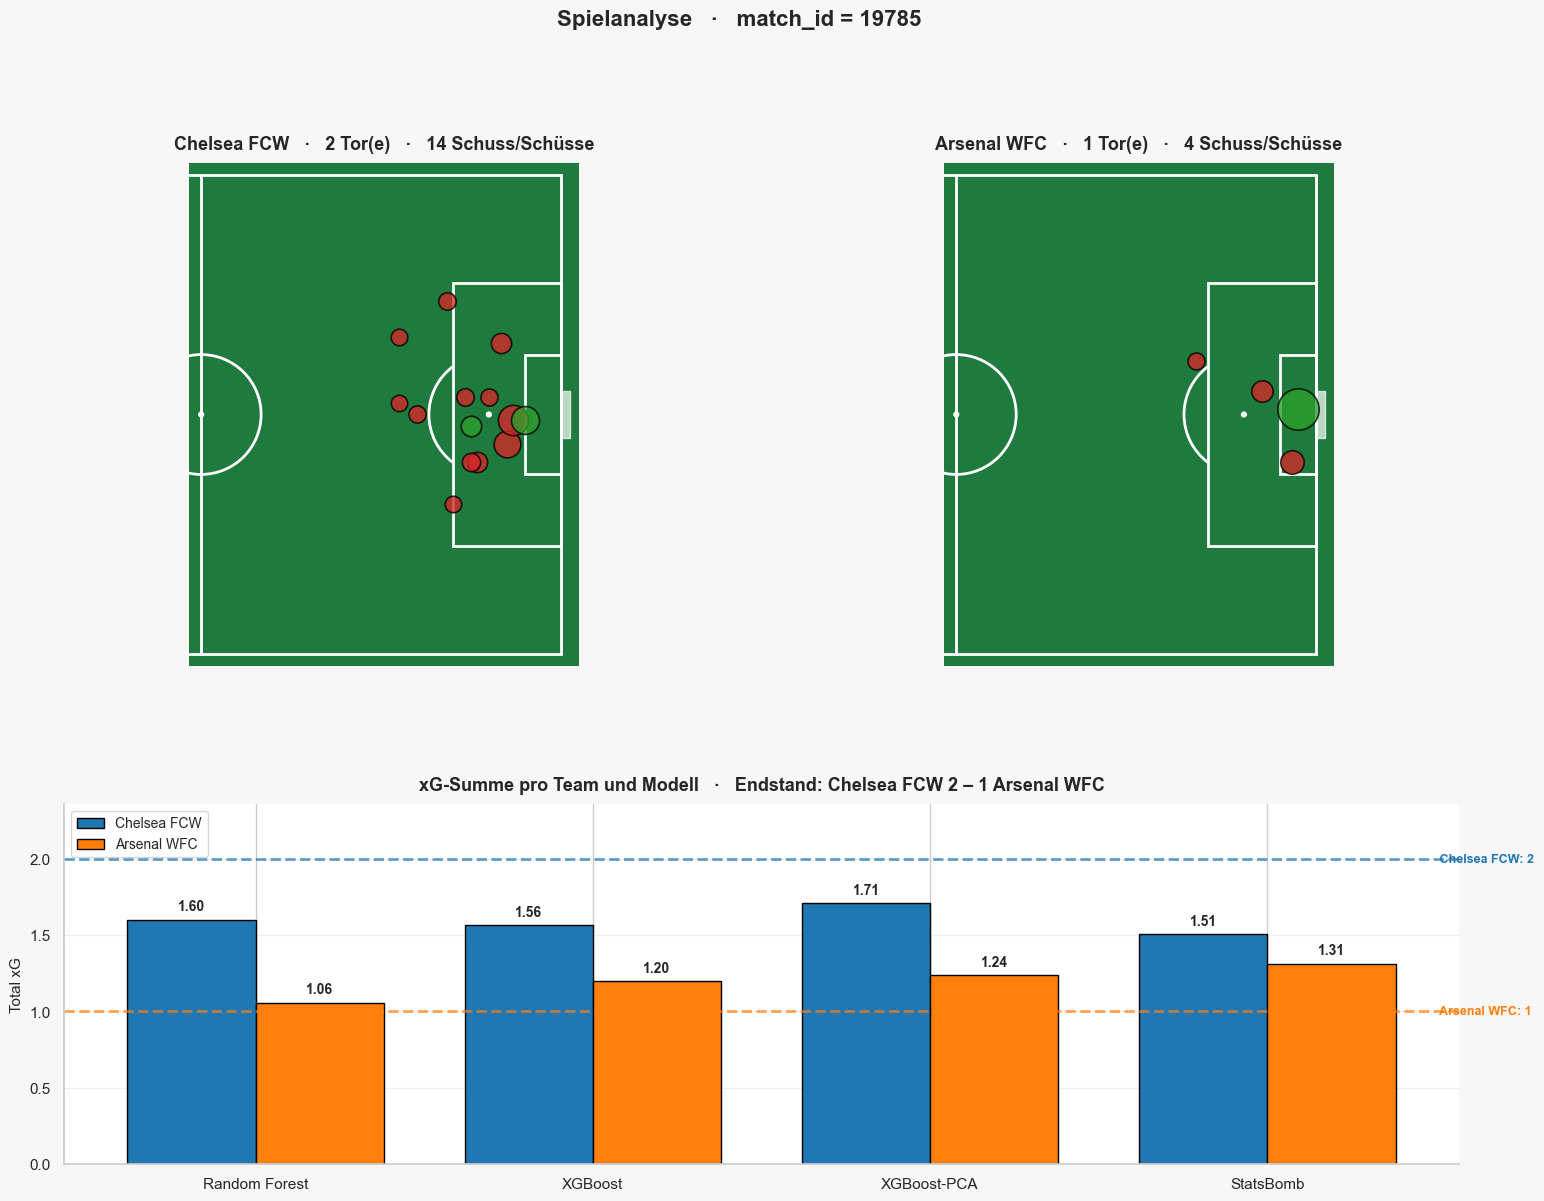


Schuss-Detail (18 Schüsse, gefilterte Daten ohne Penalties/Eigentore):


,minute,team,player,shot_outcome,rf_xg,xgb_xg,xgb_pca_xg,sb_xg
0,64,Arsenal WFC,Lia Wälti,Blocked,0.039,0.020,0.030,0.047
1,79,Arsenal WFC,Vivianne Miedema,Goal,0.732,0.894,0.900,0.886
2,85,Arsenal WFC,Vivianne Miedema,Saved,0.121,0.096,0.141,0.164
3,89,Arsenal WFC,Vivianne Miedema,Saved,0.165,0.187,0.166,0.215
4,2,Chelsea FCW,Magdalena Lilly Eriksson,Off T,0.043,0.047,0.071,0.012
5,9,Chelsea FCW,Karen Julia Carney,Blocked,0.212,0.283,0.475,0.144
6,9,Chelsea FCW,Sophie Louise Ingle,Saved,0.054,0.016,0.023,0.044
7,12,Chelsea FCW,So-Yun Ji,Blocked,0.036,0.021,0.017,0.029
8,15,Chelsea FCW,Millie Bright,Saved,0.335,0.413,0.358,0.468
9,21,Chelsea FCW,Erin Cuthbert,Blocked,0.043,0.034,0.023,0.053


In [25]:
# --- Random Match wählen (≥ 10 Schüsse für sinnvolle Analyse) ---
match_shot_counts = shots["match_id"].value_counts()
eligible_matches = match_shot_counts[match_shot_counts >= 10].index.tolist()
match_id = random.choice(eligible_matches)

match_shots = shots[shots["match_id"] == match_id].copy()
match_shots_raw = shots_raw[shots_raw["match_id"] == match_id].copy()

teams = list(match_shots_raw["team"].unique())
if len(teams) < 2:
    teams = teams + [t for t in match_shots["team"].unique() if t not in teams]
team_a, team_b = teams[0], teams[1]

# Tatsächliche Tore (aus shots_raw, inkl. Penalties)
def _goals(df, team):
    return int(((df["team"] == team) & (df["shot_outcome"] == "Goal")).sum())
goals_a = _goals(match_shots_raw, team_a)
goals_b = _goals(match_shots_raw, team_b)

# --- Predictions aller 4 Modelle ---
X_match = match_shots[feature_cols]
match_shots = match_shots.assign(
    rf_xg      = rf.predict_proba(X_match)[:, 1],
    xgb_xg     = xgb_model.predict_proba(X_match)[:, 1],
    xgb_pca_xg = xgb_pca.predict_proba(pca_pipeline.transform(X_match))[:, 1],
    sb_xg      = match_shots["shot_statsbomb_xg"].values,
)
match_shots["avg_xg"] = match_shots[["rf_xg", "xgb_xg", "xgb_pca_xg", "sb_xg"]].mean(axis=1)

model_keys = ["rf_xg", "xgb_xg", "xgb_pca_xg", "sb_xg"]
model_names = ["Random Forest", "XGBoost", "XGBoost-PCA", "StatsBomb"]
totals_a = {n: match_shots.loc[match_shots["team"] == team_a, k].sum()
            for n, k in zip(model_names, model_keys)}
totals_b = {n: match_shots.loc[match_shots["team"] == team_b, k].sum()
            for n, k in zip(model_names, model_keys)}

# --- Figure-Layout ---
fig = plt.figure(figsize=(18, 13), facecolor="#f7f7f7")
gs = fig.add_gridspec(2, 2, height_ratios=[1.4, 1.0], hspace=0.32, wspace=0.18)

# --- Pitch Team A ---
ax_a = fig.add_subplot(gs[0, 0])
draw_pitch(ax_a)
team_a_shots = match_shots[match_shots["team"] == team_a]
for _, s in team_a_shots.iterrows():
    is_goal = int(s["goal"]) == 1
    ax_a.scatter(s["x"], s["y"],
                 s=120 + 900 * max(s["avg_xg"], 0.02),
                 c="#2ca02c" if is_goal else "#d62728",
                 edgecolors="black", linewidths=1.2, alpha=0.78, zorder=5)
ax_a.set_xlim(58, 123); ax_a.set_ylim(-2, 82)
ax_a.set_title(f"{team_a}   ·   {goals_a} Tor(e)   ·   {len(team_a_shots)} Schuss/Schüsse",
               fontsize=13, fontweight="bold", pad=10)

# --- Pitch Team B ---
ax_b = fig.add_subplot(gs[0, 1])
draw_pitch(ax_b)
team_b_shots = match_shots[match_shots["team"] == team_b]
for _, s in team_b_shots.iterrows():
    is_goal = int(s["goal"]) == 1
    ax_b.scatter(s["x"], s["y"],
                 s=120 + 900 * max(s["avg_xg"], 0.02),
                 c="#2ca02c" if is_goal else "#d62728",
                 edgecolors="black", linewidths=1.2, alpha=0.78, zorder=5)
ax_b.set_xlim(58, 123); ax_b.set_ylim(-2, 82)
ax_b.set_title(f"{team_b}   ·   {goals_b} Tor(e)   ·   {len(team_b_shots)} Schuss/Schüsse",
               fontsize=13, fontweight="bold", pad=10)

# --- xG-Summen-Bar-Chart ---
ax_bar = fig.add_subplot(gs[1, :])
x_pos = np.arange(len(model_names))
width = 0.38
bars_a = ax_bar.bar(x_pos - width/2, [totals_a[m] for m in model_names],
                    width, color="#1f77b4", label=team_a,
                    edgecolor="black", linewidth=1)
bars_b = ax_bar.bar(x_pos + width/2, [totals_b[m] for m in model_names],
                    width, color="#ff7f0e", label=team_b,
                    edgecolor="black", linewidth=1)
for bar in list(bars_a) + list(bars_b):
    h = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width()/2, h + 0.04, f"{h:.2f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

ax_bar.axhline(goals_a, color="#1f77b4", ls="--", lw=2, alpha=0.7)
ax_bar.axhline(goals_b, color="#ff7f0e", ls="--", lw=2, alpha=0.7)
y_max = max(max(totals_a.values()), max(totals_b.values()), goals_a, goals_b) * 1.18
ax_bar.set_ylim(0, max(y_max, 1.5))
ax_bar.text(len(model_names) - 0.5, goals_a, f" {team_a}: {goals_a}",
            color="#1f77b4", fontsize=9, fontweight="bold", va="center", ha="left")
ax_bar.text(len(model_names) - 0.5, goals_b, f" {team_b}: {goals_b}",
            color="#ff7f0e", fontsize=9, fontweight="bold", va="center", ha="left")

ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(model_names, fontsize=11)
ax_bar.set_ylabel("Total xG", fontsize=11)
ax_bar.set_title(f"xG-Summe pro Team und Modell   ·   Endstand: "
                 f"{team_a} {goals_a} – {goals_b} {team_b}",
                 fontsize=13, fontweight="bold", pad=10)
ax_bar.legend(loc="upper left", fontsize=10)
ax_bar.grid(axis="y", alpha=0.3); ax_bar.set_axisbelow(True)
for s in ["top", "right"]:
    ax_bar.spines[s].set_visible(False)

plt.suptitle(f"Spielanalyse   ·   match_id = {match_id}",
             fontsize=16, fontweight="bold", y=0.998)
plt.show()

# --- Detail-Tabelle ---
print(f"\nSchuss-Detail ({len(match_shots)} Schüsse, gefilterte Daten ohne Penalties/Eigentore):")
detail_cols = ["minute", "team", "player", "shot_outcome",
               "rf_xg", "xgb_xg", "xgb_pca_xg", "sb_xg"]
existing_cols = [c for c in detail_cols if c in match_shots.columns]
detail = match_shots[existing_cols].copy()
for c in ["rf_xg", "xgb_xg", "xgb_pca_xg", "sb_xg"]:
    if c in detail.columns:
        detail[c] = detail[c].round(3)
display(detail.sort_values(["team", "minute"]).reset_index(drop=True))